In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from helpers.draft import ClassicalLSTM, QLSTM, StockPricePredictor
from helpers.data_sources import StockDataCollector
from tqdm import tqdm
import pandas as pd

In [12]:
def plot_comprehensive_timeseries(model, X_train, y_train, X_test, y_test, scaler, epochs):
    """
    Create a comprehensive plot showing training and prediction time series
    with ground truth and model results in one graph
    """
    model.eval()
    
    with torch.no_grad():
        # Get predictions for both training and test sets
        train_pred = model(X_train)
        test_pred = model(X_test)
        
        # Handle output shapes
        if len(train_pred.shape) > 2:
            train_pred = train_pred[:, -1, :]
        if len(test_pred.shape) > 2:
            test_pred = test_pred[:, -1, :]
        
        # Ensure shapes match
        if train_pred.shape != y_train.shape:
            train_pred = train_pred[:, :y_train.shape[1]]
        if test_pred.shape != y_test.shape:
            test_pred = test_pred[:, :y_test.shape[1]]
        
        # Convert to numpy and denormalize
        y_train_np = y_train.numpy().flatten()
        y_test_np = y_test.numpy().flatten()
        train_pred_np = train_pred.numpy().flatten()
        test_pred_np = test_pred.numpy().flatten()
        
        if scaler is not None:
            y_train_np = scaler.inverse_transform(y_train_np.reshape(-1, 1)).flatten()
            y_test_np = scaler.inverse_transform(y_test_np.reshape(-1, 1)).flatten()
            train_pred_np = scaler.inverse_transform(train_pred_np.reshape(-1, 1)).flatten()
            test_pred_np = scaler.inverse_transform(test_pred_np.reshape(-1, 1)).flatten()
            y_label = "Stock Price ($)"
        else:
            y_label = "Normalized Price"
        
        # Generate timestamps that match the actual data length
        # Start with a base date and create dates for each data point
        start_date = pd.Timestamp('2022-01-01')
        
        # Create dates for training data (one date per data point)
        train_dates = []
        current_date = start_date
        for i in range(len(y_train_np)):
            # Skip weekends
            while current_date.weekday() >= 5:  # Saturday = 5, Sunday = 6
                current_date += pd.Timedelta(days=1)
            train_dates.append(current_date)
            current_date += pd.Timedelta(days=1)
        
        # Create dates for test data (continue from where training left off)
        test_dates = []
        for i in range(len(y_test_np)):
            # Skip weekends
            while current_date.weekday() >= 5:
                current_date += pd.Timedelta(days=1)
            test_dates.append(current_date)
            current_date += pd.Timedelta(days=1)
        
        # Convert to pandas DatetimeIndex
        train_dates = pd.DatetimeIndex(train_dates)
        test_dates = pd.DatetimeIndex(test_dates)
        
        # Verify lengths match
        assert len(train_dates) == len(y_train_np), f"Train dates: {len(train_dates)}, Train data: {len(y_train_np)}"
        assert len(test_dates) == len(y_test_np), f"Test dates: {len(test_dates)}, Test data: {len(y_test_np)}"
        
        # Create the comprehensive plot
        plt.figure(figsize=(16, 10))
        
        # Main time series plot
        plt.subplot(2, 1, 1)
        
        # Plot training data
        plt.plot(train_dates, y_train_np, label='Training Ground Truth', 
                color='blue', linewidth=2, alpha=0.8)
        plt.plot(train_dates, train_pred_np, label='Training Predictions', 
                color='red', linewidth=2, alpha=0.8, linestyle='--')
        
        # Plot test data
        plt.plot(test_dates, y_test_np, label='Test Ground Truth', 
                color='green', linewidth=2, alpha=0.8)
        plt.plot(test_dates, test_pred_np, label='Test Predictions', 
                color='orange', linewidth=2, alpha=0.8, linestyle='--')
        
        # Add vertical line to separate training and test
        plt.axvline(x=train_dates[-1], color='black', linestyle=':', alpha=0.7, linewidth=2)
        plt.text(train_dates[-1] + pd.Timedelta(days=1), plt.ylim()[1] * 0.95, 'Test Split', 
                rotation=90, verticalalignment='top', fontweight='bold')
        
        plt.title(f'Comprehensive Time Series: Ground Truth vs Model Predictions ({epochs} epochs)')
        plt.xlabel('Date')
        plt.ylabel(y_label)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Format x-axis dates
        plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=1))
        plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
        plt.xticks(rotation=45)
        
        # Add performance metrics
        train_rmse = np.sqrt(np.mean((y_train_np - train_pred_np) ** 2))
        test_rmse = np.sqrt(np.mean((y_test_np - test_pred_np) ** 2))
        
        plt.text(0.02, 0.98, f'Train RMSE: {train_rmse:.4f}\nTest RMSE: {test_rmse:.4f}', 
                transform=plt.gca().transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Error analysis plot
        plt.subplot(2, 1, 2)
        
        # Calculate errors
        train_error = np.abs(y_train_np - train_pred_np)
        test_error = np.abs(y_test_np - test_pred_np)
        
        # Plot training errors
        plt.plot(train_dates, train_error, label='Training Error', 
                color='red', alpha=0.7, linewidth=1.5)
        
        # Plot test errors
        plt.plot(test_dates, test_error, label='Test Error', 
                color='orange', alpha=0.7, linewidth=1.5)
        
        # Add vertical line to separate training and test
        plt.axvline(x=train_dates[-1], color='black', linestyle=':', alpha=0.7, linewidth=2)
        plt.text(train_dates[-1] + pd.Timedelta(days=1), plt.ylim()[1] * 0.95, 'Test Split', 
                rotation=90, verticalalignment='top', fontweight='bold')
        
        plt.title('Prediction Errors Over Time')
        plt.xlabel('Date')
        plt.ylabel('Absolute Error')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Format x-axis dates for error plot
        plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=1))
        plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Print comprehensive summary
        print(f"\n�� Comprehensive Time Series Analysis:")
        print(f"   Training RMSE: {train_rmse:.4f}")
        print(f"   Test RMSE: {test_rmse:.4f}")
        print(f"   Training Period: {train_dates[0].strftime('%Y-%m-%d')} to {train_dates[-1].strftime('%Y-%m-%d')}")
        print(f"   Test Period: {test_dates[0].strftime('%Y-%m-%d')} to {test_dates[-1].strftime('%Y-%m-%d')}")

In [13]:
def run_classical_lstm(dataset_path=None, epochs=50, sequence_length=10, learning_rate=0.01):
    """
    Run Classical LSTM on specified dataset
    
    Args:
        dataset_path (str): Path to CSV file, or None for sample data
        epochs (int): Number of training epochs
        sequence_length (int): Number of time steps for prediction
        learning_rate (float): Learning rate for training
    """
    print("🚀 Classical LSTM Stock Price Prediction")
    print("=" * 50)
    
    # Initialize predictor
    predictor = StockPricePredictor(sequence_length=sequence_length)
    
    # Load data
    if dataset_path:
        print(f"📊 Loading data from: {dataset_path}")
        X_train, X_test, y_train, y_test = predictor.load_and_preprocess_data(dataset_path)
    else:
        print("📊 Using sample data")
        X_train, X_test, y_train, y_test = predictor.load_and_preprocess_data()
    
    print(f"✅ Data loaded successfully!")
    print(f"   Training samples: {X_train.shape[0]}")
    print(f"   Test samples: {X_test.shape[0]}")
    print(f"   Sequence length: {sequence_length}")
    
    # Initialize Classical LSTM
    print(f"\n🧠 Initializing Classical LSTM...")
    classical_lstm = ClassicalLSTM(input_size=1, hidden_size=7, output_size=1)
    
    # Count parameters
    total_params = sum(p.numel() for p in classical_lstm.parameters())
    print(f"   Total parameters: {total_params}")
    
    # Train model
    print(f"\n🎯 Training Classical LSTM for {epochs} epochs...")
    train_losses = predictor.train_model(classical_lstm, X_train, y_train, epochs=epochs, lr=learning_rate)
    
    # Evaluate model
    print(f"\n📈 Evaluating model...")
    rmse, accuracy = predictor.evaluate_model(classical_lstm, X_test, y_test)
    
    # Print results
    print(f"\n🏆 Results:")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   Accuracy: {accuracy:.4f}")
    
    # Plot training loss
    print(f"\n📊 Plotting training loss...")
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, 'b-', linewidth=2)
    plt.title(f'Classical LSTM Training Loss ({epochs} epochs)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Plot predictions
    print(f"\n📊 Plotting predictions...")
    predictor.plot_predictions(classical_lstm, X_test, y_test, "Classical LSTM", predictor.scaler)
    
    # Plot comprehensive time series comparison
    print(f"\n📊 Plotting comprehensive time series comparison...")
    plot_comprehensive_timeseries(classical_lstm, X_train, y_train, X_test, y_test, predictor.scaler, epochs)
    
    print(f"\n✅ Classical LSTM training completed!")
    return classical_lstm, train_losses, (rmse, accuracy)

🚀 Classical LSTM Stock Price Prediction
📊 Loading data from: data/AAPL_2022-01-01_2023-01-01.csv
📊 Loading real data from data/AAPL_2022-01-01_2023-01-01.csv
✅ Loaded 251 data points
✅ Data loaded successfully!
   Training samples: 165
   Test samples: 66
   Sequence length: 10

🧠 Initializing Classical LSTM...
   Total parameters: 288

🎯 Training Classical LSTM for 50 epochs...


Training ClassicalLSTM: 100%|██████████| 50/50 [00:00<00:00, 261.68it/s, Loss=0.034459]


📈 Evaluating model...

🏆 Results:
   RMSE: 0.2127
   Accuracy: 0.8327

📊 Plotting training loss...


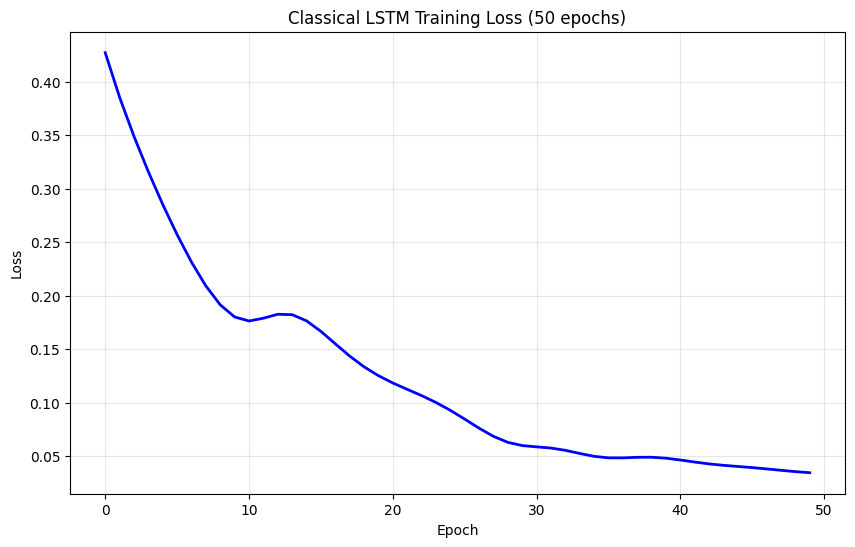


📊 Plotting predictions...


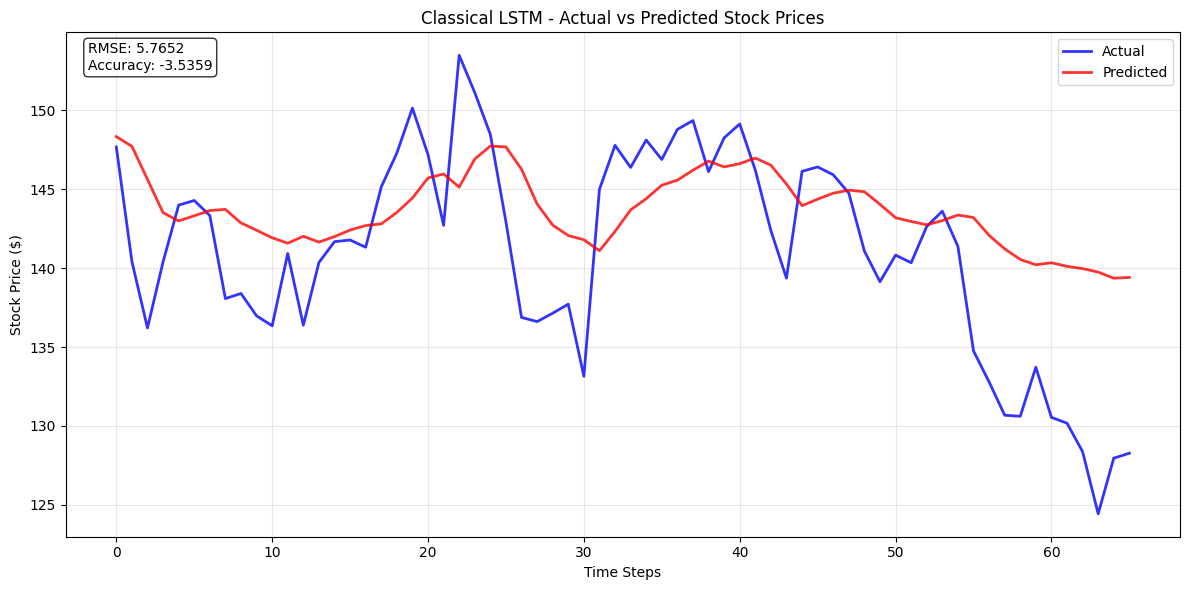


📊 Classical LSTM Prediction Performance:
   RMSE: 5.7652
   Accuracy: -3.5359

📊 Plotting comprehensive time series comparison...


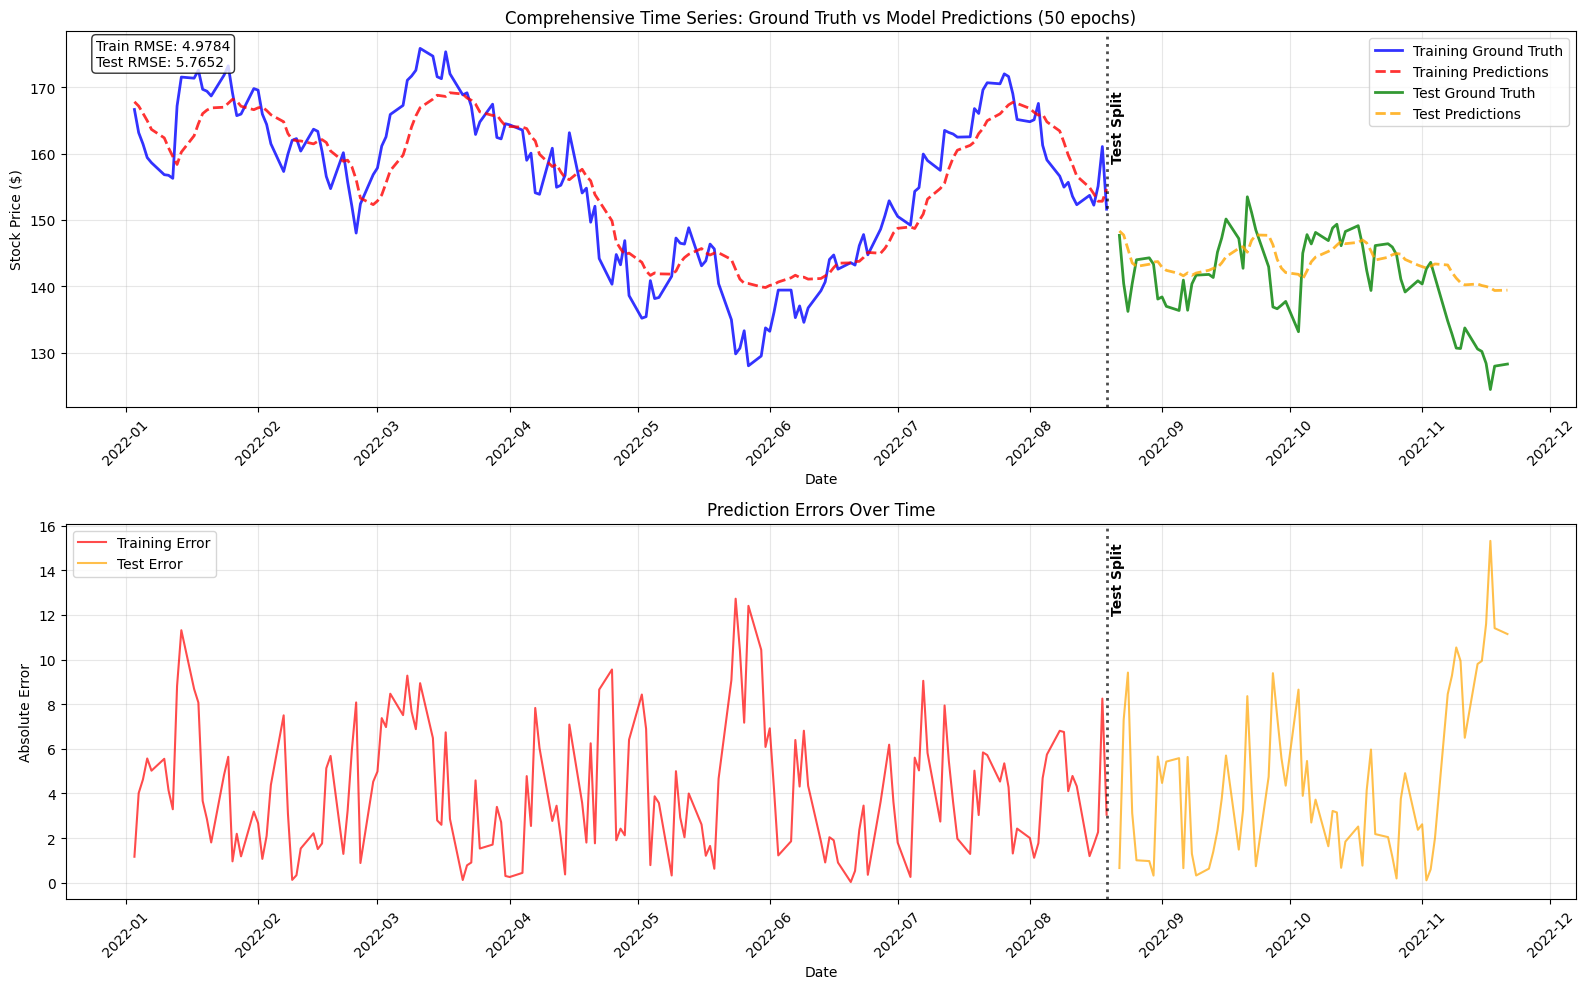


�� Comprehensive Time Series Analysis:
   Training RMSE: 4.9784
   Test RMSE: 5.7652
   Training Period: 2022-01-03 to 2022-08-19
   Test Period: 2022-08-22 to 2022-11-21

✅ Classical LSTM training completed!

📋 Final Summary:
   Dataset: data/AAPL_2022-01-01_2023-01-01.csv
   Epochs: 50
   Sequence Length: 10
   Learning Rate: 0.01
   Final RMSE: 0.2127
   Final Accuracy: 0.8327


In [14]:
dataset = 'data/AAPL_2022-01-01_2023-01-01.csv'
# dataset = 'data/GOOGL_2022-01-01_2023-01-01.csv'
# dataset = 'data/AMZN_2022-01-01_2023-01-01.csv'
# dataset = 'data/MSFT_2022-01-01_2023-01-01.csv'
# dataset = 'data/TSLA_2022-01-01_2023-01-01.csv'
epochs = 50
sequence_length = 10
learning_rate = 0.01

# Run Classical LSTM
model, losses, metrics = run_classical_lstm(
    dataset_path=dataset,
    epochs=epochs,
    sequence_length=sequence_length,
    learning_rate=learning_rate
)

# Print final summary
print(f"\n📋 Final Summary:")
print(f"   Dataset: {dataset or 'Sample Data'}")
print(f"   Epochs: {epochs}")
print(f"   Sequence Length: {sequence_length}")
print(f"   Learning Rate: {learning_rate}")
print(f"   Final RMSE: {metrics[0]:.4f}")
print(f"   Final Accuracy: {metrics[1]:.4f}")

In [15]:
def run_quantum_lstm(dataset_path=None, epochs=50, sequence_length=10, learning_rate=0.01):
    """
    Run Quantum LSTM on specified dataset
    
    Args:
        dataset_path (str): Path to CSV file, or None for sample data
        epochs (int): Number of training epochs
        sequence_length (int): Number of time steps for prediction
        learning_rate (float): Learning rate for training
    """
    print("�� Quantum LSTM Stock Price Prediction")
    print("=" * 50)
    
    # Initialize predictor
    predictor = StockPricePredictor(sequence_length=sequence_length)
    
    # Load data
    if dataset_path:
        print(f"�� Loading data from: {dataset_path}")
        X_train, X_test, y_train, y_test = predictor.load_and_preprocess_data(dataset_path)
    else:
        print("📊 Using sample data")
        X_train, X_test, y_train, y_test = predictor.load_and_preprocess_data()
    
    print(f"✅ Data loaded successfully!")
    print(f"   Training samples: {X_train.shape[0]}")
    print(f"   Test samples: {X_test.shape[0]}")
    print(f"   Sequence length: {sequence_length}")
    
    # Initialize Quantum LSTM
    print(f"\n🧠 Initializing Quantum LSTM...")
    quantum_lstm = QLSTM(input_size=1, hidden_size=7, output_size=1, n_qubits=7)
    
    # Count parameters
    total_params = sum(p.numel() for p in quantum_lstm.parameters())
    print(f"   Total parameters: {total_params}")
    print(f"   Quantum qubits: 7")
    print(f"   VQC depth: 2")
    
    # Train model
    print(f"\n�� Training Quantum LSTM for {epochs} epochs...")
    train_losses = predictor.train_model(quantum_lstm, X_train, y_train, epochs=epochs, lr=learning_rate)
    
    # Evaluate model
    print(f"\n📈 Evaluating model...")
    rmse, accuracy = predictor.evaluate_model(quantum_lstm, X_test, y_test)
    
    # Print results
    print(f"\n🏆 Results:")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   Accuracy: {accuracy:.4f}")
    
    # Plot training loss
    print(f"\n📊 Plotting training loss...")
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, 'g-', linewidth=2)
    plt.title(f'Quantum LSTM Training Loss ({epochs} epochs)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Plot predictions
    print(f"\n📊 Plotting predictions...")
    predictor.plot_predictions(quantum_lstm, X_test, y_test, "Quantum LSTM", predictor.scaler)
    
    # Plot comprehensive time series comparison
    print(f"\n📊 Plotting comprehensive time series comparison...")
    plot_comprehensive_timeseries_quantum(quantum_lstm, X_train, y_train, X_test, y_test, predictor.scaler, epochs)
    
    print(f"\n✅ Quantum LSTM training completed!")
    return quantum_lstm, train_losses, (rmse, accuracy)

def plot_comprehensive_timeseries_quantum(model, X_train, y_train, X_test, y_test, scaler, epochs):
    """
    Create a comprehensive plot showing training and prediction time series
    with ground truth and quantum model results in one graph
    """
    model.eval()
    
    with torch.no_grad():
        # Get predictions for both training and test sets
        train_pred = model(X_train)
        test_pred = model(X_test)
        
        # Handle output shapes - take only the last timestep prediction
        if len(train_pred.shape) > 2:
            train_pred = train_pred[:, -1, :]  # Shape: (batch_size, output_size)
        if len(test_pred.shape) > 2:
            test_pred = test_pred[:, -1, :]    # Shape: (batch_size, output_size)
        
        # Ensure predictions and ground truth have matching shapes
        if train_pred.shape != y_train.shape:
            # If y_train has more dimensions, squeeze it
            if len(y_train.shape) > len(train_pred.shape):
                y_train = y_train.squeeze()
            # If train_pred has more dimensions, squeeze it
            if len(train_pred.shape) > len(y_train.shape):
                train_pred = train_pred.squeeze()
            # Ensure both are 1D
            if len(train_pred.shape) == 2 and train_pred.shape[1] == 1:
                train_pred = train_pred.squeeze()
            if len(y_train.shape) == 2 and y_train.shape[1] == 1:
                y_train = y_train.squeeze()
        
        if test_pred.shape != y_test.shape:
            # If y_test has more dimensions, squeeze it
            if len(y_test.shape) > len(test_pred.shape):
                y_test = y_test.squeeze()
            # If test_pred has more dimensions, squeeze it
            if len(test_pred.shape) > len(y_test.shape):
                test_pred = test_pred.squeeze()
            # Ensure both are 1D
            if len(test_pred.shape) == 2 and test_pred.shape[1] == 1:
                test_pred = test_pred.squeeze()
            if len(y_test.shape) == 2 and y_test.shape[1] == 1:
                y_test = y_test.squeeze()
        
        # Convert to numpy and ensure 1D arrays
        y_train_np = y_train.numpy()
        y_test_np = y_test.numpy()
        train_pred_np = train_pred.numpy()
        test_pred_np = test_pred.numpy()
        
        # Ensure all arrays are 1D
        if len(y_train_np.shape) > 1:
            y_train_np = y_train_np.flatten()
        if len(y_test_np.shape) > 1:
            y_test_np = y_test_np.flatten()
        if len(train_pred_np.shape) > 1:
            train_pred_np = train_pred_np.flatten()
        if len(test_pred_np.shape) > 1:
            test_pred_np = test_pred_np.flatten()
        
        # Verify lengths match before proceeding
        assert len(train_pred_np) == len(y_train_np), f"Train pred length: {len(train_pred_np)}, Train truth length: {len(y_train_np)}"
        assert len(test_pred_np) == len(y_test_np), f"Test pred length: {len(test_pred_np)}, Test truth length: {len(y_test_np)}"
        
        # Denormalize if scaler is available
        if scaler is not None:
            y_train_np = scaler.inverse_transform(y_train_np.reshape(-1, 1)).flatten()
            y_test_np = scaler.inverse_transform(y_test_np.reshape(-1, 1)).flatten()
            train_pred_np = scaler.inverse_transform(train_pred_np.reshape(-1, 1)).flatten()
            test_pred_np = scaler.inverse_transform(test_pred_np.reshape(-1, 1)).flatten()
            y_label = "Stock Price ($)"
        else:
            y_label = "Normalized Price"
        
        # Generate timestamps that match the actual data length
        start_date = pd.Timestamp('2022-01-01')
        
        # Create dates for training data
        train_dates = []
        current_date = start_date
        for i in range(len(y_train_np)):
            while current_date.weekday() >= 5:  # Skip weekends
                current_date += pd.Timedelta(days=1)
            train_dates.append(current_date)
            current_date += pd.Timedelta(days=1)
        
        # Create dates for test data
        test_dates = []
        for i in range(len(y_test_np)):
            while current_date.weekday() >= 5:  # Skip weekends
                current_date += pd.Timedelta(days=1)
            test_dates.append(current_date)
            current_date += pd.Timedelta(days=1)
        
        # Convert to pandas DatetimeIndex
        train_dates = pd.DatetimeIndex(train_dates)
        test_dates = pd.DatetimeIndex(test_dates)
        
        # Final verification
        assert len(train_dates) == len(y_train_np), f"Train dates: {len(train_dates)}, Train data: {len(y_train_np)}"
        assert len(test_dates) == len(y_test_np), f"Test dates: {len(test_dates)}, Test data: {len(y_test_np)}"
        
        # Create the comprehensive plot
        plt.figure(figsize=(16, 10))
        
        # Main time series plot
        plt.subplot(2, 1, 1)
        
        # Plot training data
        plt.plot(train_dates, y_train_np, label='Training Ground Truth', 
                color='blue', linewidth=2, alpha=0.8)
        plt.plot(train_dates, train_pred_np, label='Training Predictions (Quantum)', 
                color='purple', linewidth=2, alpha=0.8, linestyle='--')
        
        # Plot test data
        plt.plot(test_dates, y_test_np, label='Test Ground Truth', 
                color='green', linewidth=2, alpha=0.8)
        plt.plot(test_dates, test_pred_np, label='Test Predictions (Quantum)', 
                color='magenta', linewidth=2, alpha=0.8, linestyle='--')
        
        # Add vertical line to separate training and test
        plt.axvline(x=train_dates[-1], color='black', linestyle=':', alpha=0.7, linewidth=2)
        plt.text(train_dates[-1] + pd.Timedelta(days=1), plt.ylim()[1] * 0.95, 'Test Split', 
                rotation=90, verticalalignment='top', fontweight='bold')
        
        plt.title(f'Quantum LSTM Time Series: Ground Truth vs Quantum Predictions ({epochs} epochs)')
        plt.xlabel('Date')
        plt.ylabel(y_label)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Format x-axis dates
        plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=1))
        plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
        plt.xticks(rotation=45)
        
        # Calculate RMSE correctly - ensure arrays are properly aligned
        train_rmse = np.sqrt(np.mean((y_train_np - train_pred_np) ** 2))
        test_rmse = np.sqrt(np.mean((y_test_np - test_pred_np) ** 2))
        
        # Add performance metrics
        plt.text(0.02, 0.98, f'Training RMSE: {train_rmse:.4f}\nTest RMSE: {test_rmse:.4f}', 
                transform=plt.gca().transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Error analysis plot
        plt.subplot(2, 1, 2)
        
        # Calculate errors
        train_error = np.abs(y_train_np - train_pred_np)
        test_error = np.abs(y_test_np - test_pred_np)
        
        # Plot training errors
        plt.plot(train_dates, train_error, label='Training Error (Quantum)', 
                color='purple', alpha=0.7, linewidth=1.5)
        
        # Plot test errors
        plt.plot(test_dates, test_error, label='Test Error (Quantum)', 
                color='magenta', alpha=0.7, linewidth=1.5)
        
        # Add vertical line to separate training and test
        plt.axvline(x=train_dates[-1], color='black', linestyle=':', alpha=0.7, linewidth=2)
        plt.text(train_dates[-1] + pd.Timedelta(days=1), plt.ylim()[1] * 0.95, 'Test Split', 
                rotation=90, verticalalignment='top', fontweight='bold')
        
        plt.title('Quantum LSTM Prediction Errors Over Time')
        plt.xlabel('Date')
        plt.ylabel('Absolute Error')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Format x-axis dates for error plot
        plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=1))
        plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Print comprehensive summary
        print(f"\n🔮 Quantum LSTM Time Series Analysis:")
        print(f"   Training RMSE: {train_rmse:.4f}")
        print(f"   Test RMSE: {test_rmse:.4f}")
        print(f"   Training Period: {train_dates[0].strftime('%Y-%m-%d')} to {train_dates[-1].strftime('%Y-%m-%d')}")
        print(f"   Test Period: {test_dates[0].strftime('%Y-%m-%d')} to {test_dates[-1].strftime('%Y-%m-%d')}")
        print(f"   Training samples: {len(y_train_np)}")
        print(f"   Test samples: {len(y_test_np)}")
        print(f"   Quantum qubits: 7")
        print(f"   VQC depth: 2")

�� Quantum LSTM Stock Price Prediction
�� Loading data from: data/AAPL_2022-01-01_2023-01-01.csv
📊 Loading real data from data/AAPL_2022-01-01_2023-01-01.csv
✅ Loaded 251 data points
✅ Data loaded successfully!
   Training samples: 165
   Test samples: 66
   Sequence length: 10

🧠 Initializing Quantum LSTM...
   Total parameters: 266
   Quantum qubits: 7
   VQC depth: 2

�� Training Quantum LSTM for 5 epochs...


Training QLSTM: 100%|██████████| 5/5 [02:25<00:00, 29.16s/it, Loss=0.259288]



📈 Evaluating model...



🏆 Results:
   RMSE: 0.3821
   Accuracy: 0.6926

📊 Plotting training loss...


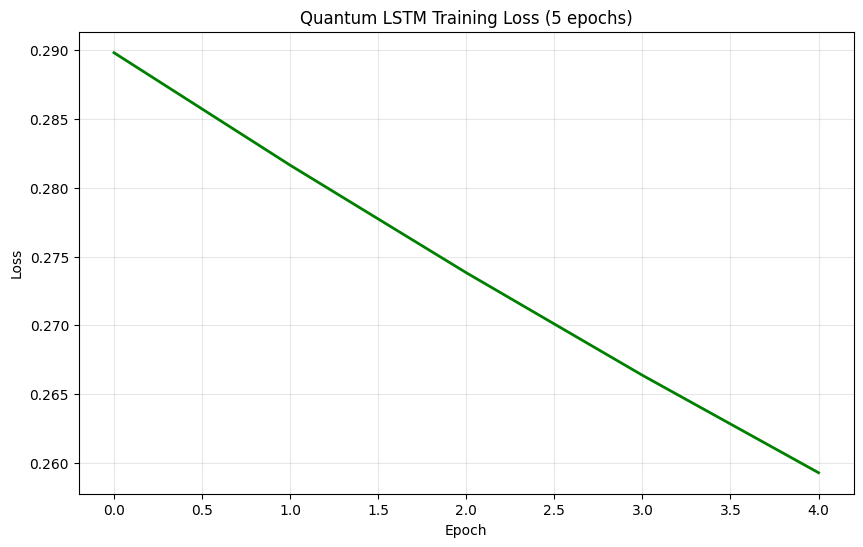


📊 Plotting predictions...


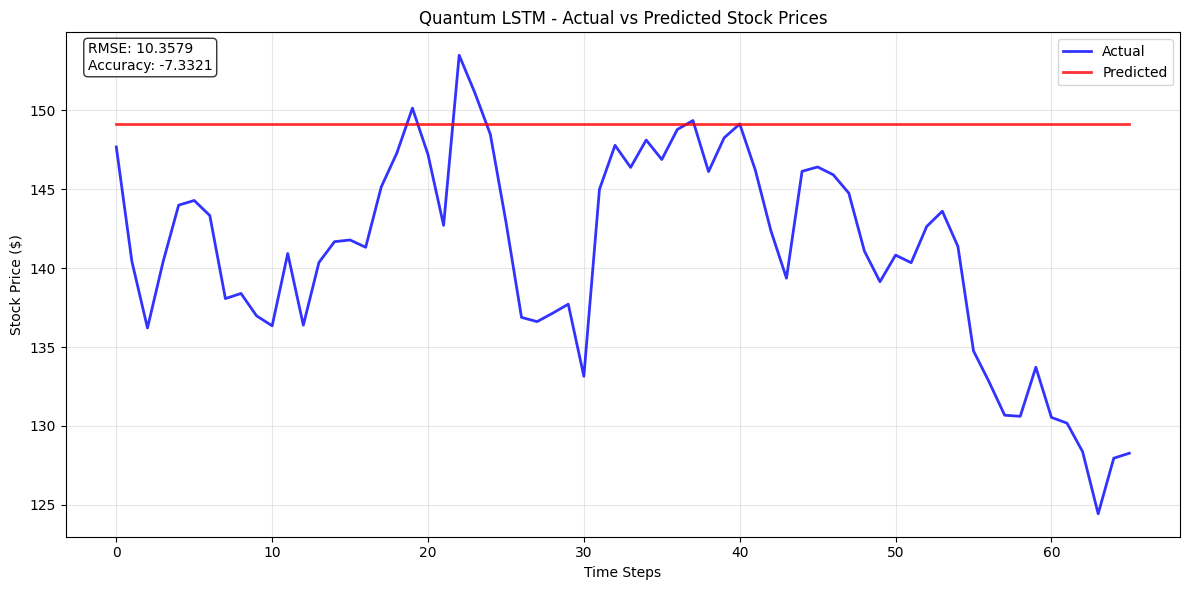


📊 Quantum LSTM Prediction Performance:
   RMSE: 10.3579
   Accuracy: -7.3321

📊 Plotting comprehensive time series comparison...


AssertionError: Train pred length: 1650, Train truth length: 165

In [18]:
dataset = 'data/AAPL_2022-01-01_2023-01-01.csv'
# dataset = 'data/GOOGL_2022-01-01_2023-01-01.csv'
# dataset = 'data/AMZN_2022-01-01_2023-01-01.csv'
# dataset = 'data/MSFT_2022-01-01_2023-01-01.csv'
# dataset = 'data/TSLA_2022-01-01_2023-01-01.csv'
epochs = 5
sequence_length = 10
learning_rate = 0.01

# Run Classical LSTM
model, losses, metrics = run_quantum_lstm(
    dataset_path=dataset,
    epochs=epochs,
    sequence_length=sequence_length,
    learning_rate=learning_rate
)

# Print final summary
print(f"\n📋 Final Summary:")
print(f"   Dataset: {dataset or 'Sample Data'}")
print(f"   Epochs: {epochs}")
print(f"   Sequence Length: {sequence_length}")
print(f"   Learning Rate: {learning_rate}")
print(f"   Final RMSE: {metrics[0]:.4f}")
print(f"   Final Accuracy: {metrics[1]:.4f}")